<a href="https://colab.research.google.com/github/mori-mkm/UFSCar/blob/main/Lab1_Mineracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Importar bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
# 2. Carregar o dataset salvo
df = pd.read_csv("dataset.csv")
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.147724,-0.003773,2.544985,-0.354103,1.673940,-1.821854,0.569402,1.323842,0.034862,-0.017273,0
1,-0.614253,1.793519,-0.592136,1.507098,1.412381,2.474119,-1.778449,0.290994,0.063540,1.661094,0
2,-0.173097,-0.185758,-0.907085,1.056614,-0.236761,0.495322,-0.352325,-0.147480,0.671742,0.983924,0
3,-1.455648,0.514883,0.677413,0.656777,-0.499840,-0.677713,-1.310922,0.834774,0.279748,-1.680895,1
4,-1.942092,-0.523286,-6.595744,2.412010,0.211565,4.376810,-2.752751,-2.067694,1.967541,-0.203317,0


In [ ]:

# Separar variáveis explicativas e alvo
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
# 3. Dividir em treino e teste
# Use stratify=y para manter o desbalanceamento nas duas partes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

In [ ]:
# 4. Treinar modelo de regressão logística
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# # 5. Gerar previsões com threshold 0.5
y_proba = modelo.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

In [ ]:
# 6. Construir matriz de confusão
# A partir da matriz, os alunos devem calcular manualmente: acurácia, precisão, recall e F1-score
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(matriz)
acuracia = (matriz[0,0] + matriz[1,1]) / sum(sum(matriz))
precisao = matriz[0,0] / (matriz[0,0] + matriz[1,0])
recall = matriz[1,1] / (matriz[1,1] + matriz[1,0])
f1 = 2* ((precisao * recall)/ (precisao + recall))
print('acuracia=',acuracia)
print('precisao=',precisao)
print('recall=',recall)
print('f1=',f1)

Matriz de Confusão:
[[443   0]
 [ 37  20]]
acuracia= 0.926
precisao= 0.9229166666666667
recall= 0.3508771929824561
f1= 0.5084502596769102


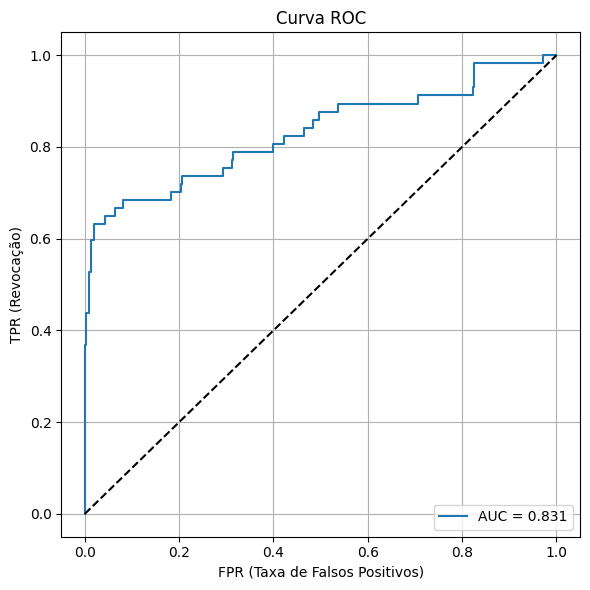

In [ ]:
# # 7. Plotar curva ROC e calcular AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR (Taxa de Falsos Positivos)")
plt.ylabel("TPR (Revocação)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 9. Desafio: encontrar o melhor threshold com base no F1-score

# a) Crie uma lista de thresholds entre 0 e 1 (ex: np.linspace(0, 1, 100))
thresholds = np.linspace(0, 1, 100)

# b) Para cada threshold, calcule as previsões binárias e a matriz de confusão
# c) A partir da matriz, calcule manualmente:
# d) Guarde o F1-score para cada threshold
f1 = []

for i in range(len(thresholds)):
  y_proba = modelo.predict_proba(X_test)[:, 1]
  y_pred = (y_proba >= thresholds[i]).astype(int)
  matriz = confusion_matrix(y_test, y_pred)
  precisao = matriz[0,0] / (matriz[0,0] + matriz[0, 1])
  recall = matriz[1,1] / (matriz[1,1] + matriz[1,0])
  f1.append((2*(precisao * recall)/ (precisao + recall)))

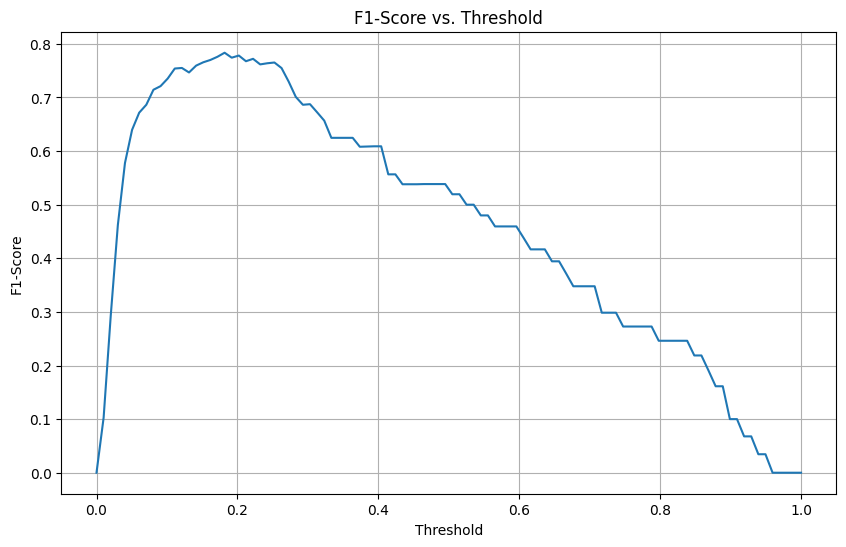

In [ ]:
# e) Plote o gráfico do F1-score em função do threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1)
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Threshold")
plt.grid(True)
plt.show()


In [ ]:
# f) Escolha o melhor threshold e refaça a matriz de confusão final
threshold_ = thresholds[np.argmax(f1)]
print(f"Melhor threshold: {threshold_}")

y_pred_ = (y_proba >= threshold_).astype(int)
matriz_ = confusion_matrix(y_test, y_pred_)
print("Matriz de confusão com melhor threshold:")
print(matriz_)

acuracia_ = (matriz_[0,0] + matriz_[1,1]) / sum(sum(matriz_))
precisao_ = matriz_[0,0] / (matriz_[0,0] + matriz_[1,0])
recall_ = matriz_[1,1] / (matriz_[1,1] + matriz_[1,0])
f1_ = 2* ((precisao_ * recall_)/ (precisao_ + recall_))

print('acuracia=',acuracia_)
print('precisao=',precisao_)
print('recall=',recall_)
print('f1=',f1_)



Melhor threshold: 0.18181818181818182
Matriz de confusão com melhor threshold:
[[406  37]
 [ 18  39]]
acuracia= 0.89
precisao= 0.9575471698113207
recall= 0.6842105263157895
f1= 0.7981249054891879


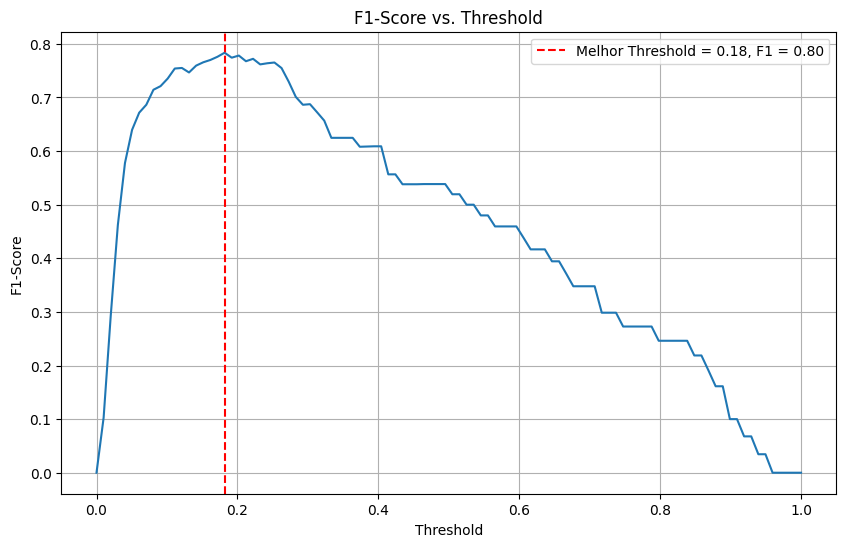

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1)
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Threshold")
plt.grid(True)

# Add a vertical line for the best threshold
plt.axvline(x=threshold_, color='r', linestyle='--', label=f'Melhor Threshold = {threshold_:.2f}, F1 = {f1_:.2f}')
plt.legend()

plt.show()
